# Adaptive ICL

https://github.com/ManishChandra12/adaptiveICL  

- total number of train samples: 1000
- total number of test&nbsp; samples: 500
- model: Casual LM ("meta-llama/llama-2-7b-hf")
- dataset: agnews
- the test set is the same as in the other notebooks (mulitclassRoBERTA and fewshotCasualLM)
- from the train set will be take 10% of sample as dev set, for choosing the best k-predictor

TESTS:
1. Llama-2-7b-hf - 500 real
2. Llama-2-7b-hf - 1000 real
3. Llama-2-7b-hf - 500 real + 500 targeted augmentation
4. Llama-2-7b-hf - 1000 targeted augmentation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from __future__ import print_function
import subprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import time

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise

from src._utils._helpers import get_generated_examples_df

In [ ]:
### LOAD DATA ###
# real data
real_train_df = pd.read_csv("real_data/train/agnewstrainAll.csv").rename(columns={"2": "text", "3": "label"})
real_train_df.drop(columns=["0", "1"], inplace=True)

# Take 500 samples for test set
real_train_df, test_df_500 = train_test_split(real_train_df, test_size=500, random_state=42, stratify=real_train_df["label"])
# Store the dev set into a CSV file
# dev_df.to_csv(os.path.join(FOLDER_DIR, "dev_set.csv"), index=False)
# dev_df_500 = pd.read_csv("src/agnews/experiments/RoBERTA_500samples/dev_set.csv")
# same 500 real train data used for training RoBERTa
real_train_df_500RoBERTa = pd.read_csv("src/agnews/experiments/RoBERTA_500samples/exp_500real/train.csv")
# real_train_df_500RoBERTa = real_train_df.sample(n=500, random_state=42)

# synthetic data
syn_targeted_df1, _ = get_generated_examples_df("synthetic_data/datasets/DeepSeek-R1-Distill-Qwen-1.5B/syn_agnews_targeted+tags_500.json")
syn_targeted_df2, _ = get_generated_examples_df("synthetic_data/datasets/DeepSeek-R1-Distill-Qwen-1.5B/syn_agnews_targeted+tags_500_2.json")
syn_targeted_df = pd.concat([syn_targeted_df1, syn_targeted_df2], ignore_index=True)
syn_targeted_df = syn_targeted_df.drop(columns=["phenomena"])

print(f"Real train set     : {real_train_df.shape}")
print(f"Real test set      : {test_df_500.shape}")
print(f"Synthetic train set: {syn_targeted_df.shape}")
print(f"Columns: {real_train_df.columns}")

Real train set     : (2179, 2)
Real test set      : (500, 2)
Synthetic train set: (1000, 2)
Columns: Index(['text', 'label'], dtype='object')


In [3]:
# go to AICL directory

HF_TOKEN = open("./src/_utils/hf_token.txt","r").read() # your huggingface token
HF_CACHE_DIR = "/home/ghi/.cache/huggingface/hub" # where are stored the model

print(os.getcwd())
os.chdir("./src/_utils/_adaptiveICL")
print(os.getcwd())

os.makedirs("./results/", exist_ok=True)

/home/ghi/Documents/bai-thesis-nlp
/home/ghi/Documents/bai-thesis-nlp/src/_utils/_adaptiveICL


In [4]:
# Huggingface login for LLAMA

command = [
    "huggingface-cli", "login",
    "--token", HF_TOKEN
]

result = subprocess.run(command, capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /home/ghi/.cache/huggingface/token
Login successful




In [ ]:
def compute_metrics(df):
    # Single-label multi-class classification
    y_true = df["label"].tolist()
    y_pred = df["pred"].tolist()

    return {
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }


def execute(cmd):
    # Execute a command in a subprocess and yield the output line by line
    popen = subprocess.Popen(cmd, stdout=subprocess.PIPE, universal_newlines=True)
    for stdout_line in iter(popen.stdout.readline, ""):
        yield stdout_line 
    popen.stdout.close()
    return_code = popen.wait()
    if return_code:
        raise subprocess.CalledProcessError(return_code, cmd)
    

def prepare_data_kpredictor(dataset, model_name="meta-llama/llama-2-7b-hf"):
    """
    Before running the AICL, we need to prepare the data for the kpredictor
    This measns that we need to run k-shot classification on the dataset
    for each k from 1 to 10 (K_max)
    """
    command = [
        "python", "-m", "src.main",
        "--prepare",
        "--dataset", dataset,
        "--method", "dynamic",
        "--model_name",  model_name,
        "--oracle_split", "train",
        "--cache_dir", HF_CACHE_DIR,
    ]

    t0 = time.time()
    for line in execute(command):
        print(line, end="")
    print(f"Time: {time.time() - t0:.2f} seconds")


def run_aicl(dataset, model_name="meta-llama/llama-2-7b-hf"):
    """
    Run the AICL on the dataset
    Once we have the labels for the k-shot classification,
    we can train the kpredictor and then run the AICL
    """
    command = [
        "python", "-m", "src.main",
        "--dataset", dataset, 
        "--method", "dynamic",
        "--model_name", model_name,
        "--cache_dir", HF_CACHE_DIR,
        "--save_preds"
    ]

    t0 = time.time()
    for line in execute(command):
        print(line, end="")
    print(f"Time: {time.time() - t0:.2f} seconds")


def move_and_get_results(config):
    # get output of classification
    preds_file = "./results/pred_label_agnews_"+config+"_llama-2-7b-hf_dynamic.csv"
    preds = pd.read_csv(preds_file)
    # store it in agnews/experiments/adaptiveICL
    new_dir = "../../agnews/experiments/adaptiveICL_1000samples"
    os.makedirs(new_dir, exist_ok=True)
    preds.to_csv(os.path.join(new_dir, "pred_label_agnews_llama-2-7b-hf_dynamic_"+config+".csv"), index=False)

    # compute metrics
    metrics = compute_metrics(preds)
    metrics['name'] = "llama2_"+config
    return metrics

In [6]:
### Prepare all the data folders for the different configurations of data
### Save data in _adaptiveICL/data

# train: 500 real
path_0 = "data/agnews_500real/"
os.makedirs(path_0, exist_ok=True)
test_df_500.to_csv(os.path.join(path_0, "test.csv"), index=False)
real_train_df_500RoBERTa.to_csv(os.path.join(path_0, "train.csv"), index=False)
print(f"Train set 500 real: {real_train_df_500RoBERTa.shape}")

# train: 1000 real
path_1 = "data/agnews_1000real/"
os.makedirs(path_1, exist_ok=True)
test_df_500.to_csv(os.path.join(path_1, "test.csv"), index=False)
train_df1 = real_train_df.sample(n=1000, random_state=42).reset_index(drop=True)
train_df1.to_csv(os.path.join(path_1, "train.csv"), index=False)
print(f"Train set 1000 real: {train_df1.shape}")

# train: 500 real + 500 synthetic
path_2 = "data/agnews_500real+500syn/"
os.makedirs(path_2, exist_ok=True)
test_df_500.to_csv(os.path.join(path_2, "test.csv"), index=False)
train_df2 = pd.concat([
                    real_train_df.sample(n=500, random_state=42).reset_index(drop=True), 
                    syn_targeted_df.sample(n=500, random_state=42).reset_index(drop=True)
                ], ignore_index=True)
train_df2.to_csv(os.path.join(path_2, "train.csv"), index=False)
print(f"Train set 500 real + 500 synthetic: {train_df2.shape}")


# train: 1000 synthetic
path_3 = "data/agnews_1000syn/"
os.makedirs(path_3, exist_ok=True)
test_df_500.to_csv(os.path.join(path_3, "test.csv"), index=False)
train_df3 = syn_targeted_df.sample(n=1000, random_state=42).reset_index(drop=True)
train_df3.to_csv(os.path.join(path_3, "train.csv"), index=False)
print(f"Train set 1000 synthetic: {train_df3.shape}")

Train set 500 real: (500, 2)
Train set 1000 real: (1000, 2)
Train set 500 real + 500 synthetic: (1000, 2)
Train set 1000 synthetic: (1000, 2)


In [7]:
# # see documnetation AdaptiveICL
# command = [
#     "python", "-m", "src.main", "--help"
# ]

# for line in execute(command):
#     print(line, end="")

## 1. Llama-2-7b-hf - 500 real

In [8]:
# prepare data for training the k-predictor
config = "500real"
DATASET = "agnews_"+config
t0 = time.time()
prepare_data_kpredictor(DATASET)
prepare_time = time.time() - t0
# TIME: 65m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews_500real', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:15<00:00,  7.54s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 59, 1: 153, 2: 59, 3: 179}
Dev labels count after splitting  : {0: 10, 1: 17, 2: 5, 3: 18}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 450
Length of test set : 500
Length of dev set  : 50
Train example at 0th  index:  {
  "guid": "train-72",
  "label": 1,
  "text_a": "Bayern Munich coach Felix Magath, who criticised his new players for the time they spent putting on hair gel, warned on Friday that his honeymoon period is over and he plans to get tougher with the squad.",
  "text_b": ""
}



100%|██████████| 450/450 [32:02<00:00,  4.27s/it]


Train set size :  314
Val set size   :  68
Test set size  :  68
best_k
0     192
1     103
2      59
3      31
4      21
5      16
9       8
7       6
6       6
10      5
8       3
Name: count, dtype: int64
best_k
0     134
1      72
2      41
3      21
4      15
5      12
9       6
6       4
7       4
10      3
8       2
Name: count, dtype: int64
best_k
0     29
1     15
2      9
3      5
4      3
5      2
7      1
9      1
6      1
8      1
10     1
Name: count, dtype: int64
best_k
0     29
1     16
2      9
3      5
4      3
5      2
9      1
10     1
7      1
6      1
Name: count, dtype: int64
{0: 192, 1: 103, 2: 59, 3: 31, 4: 21, 5: 16, 6: 6, 7: 6, 8: 3, 9: 8, 10: 5}
Mean k:  1.56
Mean Sequence length: 196.48
Min Sequence length : 66
Max Sequence length : 958
95th percentile  : 492.0
99th percentile  : 709.55
99.9th percentile: 881.67
Classification Report:
              precision    recall  f1-score   support

           0     0.9672    1.0000    0.9833        59
           1    

In [9]:
t0 = time.time()
run_aicl(DATASET)
eval_time = time.time() - t0
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews_500real', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:14<00:00,  7.30s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 59, 1: 153, 2: 59, 3: 179}
Dev labels count after splitting  : {0: 10, 1: 17, 2: 5, 3: 18}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 450
Length of test set : 500
Length of dev set  : 50
Train example at 0th  index:  {
  "guid": "train-72",
  "label": 1,
  "text_a": "Bayern Munich coach Felix Magath, who criticised his new players for the time they spent putting on hair gel, warned on Friday that his honeymoon period is over and he plans to get tougher with the squad.",
  "text_b": ""
}

len train: 314
Epoch:  1 | Train Loss: 0.7015 | Val Loss: 0.6906
Epoch:  2 | Train Loss: 0.6863 | Val Loss: 0.6699
Epoch:  3 | Train Loss: 0.6600 | Val Loss: 0.6446
Epoch:  4 | Train Loss: 0.6373 | Val Loss: 0.6179
Epoch:  5 | Train Loss: 0.6015 | Val Loss: 0.5947
Epoch:  6 | Train Loss: 0.5889 | Val Loss: 0.5795
Epoch:  7 | Train Loss: 0.5606 | Val Loss: 0.5724
Epoch:  8 | Train Loss: 0.5881 |

100%|██████████| 500/500 [02:45<00:00,  3.03it/s]


Predictions count {3: 130, 4: 3, 5: 305, 6: 10, 10: 52}
Mean k:  5.01
Mean Sequence length: 415.65
Min Sequence length : 199
Max Sequence length : 1022
95th percentile  : 732.05
99th percentile  : 895.27
99.9th percentile: 1005.03
Classification Report:
              precision    recall  f1-score   support

           0     0.7727    0.8226    0.7969        62
           1     1.0000    0.7273    0.8421       187
           2     0.4242    0.6462    0.5122        65
           3     0.8141    0.8710    0.8416       186

    accuracy                         0.7820       500
   macro avg     0.7528    0.7667    0.7482       500
weighted avg     0.8278    0.7820    0.7934       500

Time: 269.04 seconds


In [12]:
results = []
metrics = move_and_get_results(config)
metrics["prepare_time"] = prepare_time
metrics["eval_time"] = eval_time
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.782, 'f1_macro': 0.748183456666889, 'accuracy': 0.782, 'name': 'llama2_500real', 'prepare_time': 1946.2155494689941, 'eval_time': 269.03638553619385}


## 2. Llama-2-7b-hf - 1000 real

In [ ]:
### Fixed ICL
# command = [
#     "python", "-m", "src.main",
#     "--dataset", "agnews_1000real",
#     "--method", "static",
#     "--model_name", "meta-llama/llama-2-7b-hf",
#     "--static_split", "dev",
#     "--K_max", "2",
#     "--cache_dir", HF_CACHE_DIR,
# ]

# for line in execute(command):
#     print(line, end="")

In [ ]:
# prepare data for training the k-predictor
config = "1000real"
DATASET = "agnews_"+config
t0 = time.time()
prepare_data_kpredictor(DATASET)
prepare_time = time.time() - t0
# TIME: 65m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews_1000real', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:15<00:00,  7.67s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 118, 1: 327, 2: 111, 3: 344}
Dev labels count after splitting  : {0: 14, 1: 27, 2: 19, 3: 40}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 1,
  "text_a": "The same day the Houston Astros announced that pitcher Andy Pettitte would have surgery on his troublesome left elbow next week, Roger Clemens left last night #39;s game against the Philadelphia Phillies with a strained right calf. ",
  "text_b": ""
}



100%|██████████| 900/900 [1:05:30<00:00,  4.37s/it]


Train set size :  630
Val set size   :  135
Test set size  :  135
best_k
0     366
1     187
2     151
3      66
4      44
5      26
10     16
6      16
7      11
9      10
8       7
Name: count, dtype: int64
best_k
0     256
1     131
2     105
3      46
4      31
5      18
6      12
10     12
9       7
7       7
8       5
Name: count, dtype: int64
best_k
0     55
1     28
2     23
3     10
4      6
5      4
6      2
9      2
7      2
10     2
8      1
Name: count, dtype: int64
best_k
0     55
1     28
2     23
3     10
4      7
5      4
10     2
6      2
7      2
8      1
9      1
Name: count, dtype: int64
{0: 366, 1: 187, 2: 151, 3: 66, 4: 44, 5: 26, 6: 16, 7: 11, 8: 7, 9: 10, 10: 16}
Mean k:  1.6355555555555557
Mean Sequence length: 204.12
Min Sequence length : 61
Max Sequence length : 1070
95th percentile  : 470.2
99th percentile  : 739.0
99.9th percentile: 894.7
Classification Report:
              precision    recall  f1-score   support

           0     0.9487    0.9407    0.94

In [ ]:
t0 = time.time()
run_aicl(DATASET)
eval_time = time.time() - t0
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews_1000real', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:15<00:00,  7.88s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 118, 1: 327, 2: 111, 3: 344}
Dev labels count after splitting  : {0: 14, 1: 27, 2: 19, 3: 40}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 1,
  "text_a": "The same day the Houston Astros announced that pitcher Andy Pettitte would have surgery on his troublesome left elbow next week, Roger Clemens left last night #39;s game against the Philadelphia Phillies with a strained right calf. ",
  "text_b": ""
}

len train: 630
Epoch:  1 | Train Loss: 0.6894 | Val Loss: 0.6731
Epoch:  2 | Train Loss: 0.6652 | Val Loss: 0.6407
Epoch:  3 | Train Loss: 0.6257 | Val Loss: 0.6047
Epoch:  4 | Train Loss: 0.5970 | Val Loss: 0.5790
Epoch:  5 | Train Loss: 0.5658 | Val Loss: 0.5693
Epoch:  6 | Train Loss: 0.5573 | Val Loss: 0.5655
Epoch:  7 | Train Loss: 0.5480 | Val Loss: 0.5563

100%|██████████| 500/500 [02:46<00:00,  3.01it/s]


Predictions count {0: 4, 1: 18, 2: 3, 3: 2, 4: 227, 5: 105, 6: 9, 7: 46, 8: 69, 9: 2, 10: 15}
Mean k:  5.12
Mean Sequence length: 424.74
Min Sequence length : 77
Max Sequence length : 1234
95th percentile  : 664.45
99th percentile  : 871.71
99.9th percentile: 1230.01
Classification Report:
              precision    recall  f1-score   support

           0     0.6901    0.7903    0.7368        62
           1     1.0000    0.6471    0.7857       187
           2     0.4078    0.6462    0.5000        65
           3     0.7854    0.8656    0.8235       186

    accuracy                         0.7460       500
   macro avg     0.7208    0.7373    0.7115       500
weighted avg     0.8047    0.7460    0.7566       500

Time: 248.58 seconds


In [ ]:
metrics = move_and_get_results(config)
metrics["prepare_time"] = prepare_time
metrics["eval_time"] = eval_time
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.746, 'f1_macro': 0.7115214506855374, 'accuracy': 0.746, 'name': 'llama2_1000real'}


## 3. Llama-2-7b-hf - 500 real + 500 targeted aug

In [23]:
# prepare data for training the k-predictor
config = "500real+500syn"
DATASET = "agnews_"+config
t0 = time.time()
prepare_data_kpredictor(DATASET)
prepare_time = time.time() - t0
# TIME: 55m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews_500real+500syn', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:16<00:00,  8.15s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 247, 1: 211, 2: 149, 3: 293}
Dev labels count after splitting  : {0: 23, 1: 22, 2: 20, 3: 35}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Climate change is a critical issue affecting various industries. This document examines the impact of climate change on industries and the strategies businesses are using to mitigate these effects.",
  "text_b": ""
}



100%|██████████| 900/900 [55:07<00:00,  3.67s/it]  


Train set size :  630
Val set size   :  135
Test set size  :  135
best_k
0     495
1     167
2      94
3      36
4      32
5      20
8      17
6      13
10     12
9       7
7       7
Name: count, dtype: int64
best_k
0     347
1     117
2      66
3      26
4      22
5      14
8      11
6       9
10      8
7       5
9       5
Name: count, dtype: int64
best_k
0     74
1     25
2     14
4      5
3      5
5      3
8      3
6      2
10     2
7      1
9      1
Name: count, dtype: int64
best_k
0     74
1     25
2     14
4      5
3      5
8      3
5      3
6      2
10     2
7      1
9      1
Name: count, dtype: int64
{0: 495, 1: 167, 2: 94, 3: 36, 4: 32, 5: 20, 6: 13, 7: 7, 8: 17, 9: 7, 10: 12}
Mean k:  1.2633333333333334
Mean Sequence length: 154.03
Min Sequence length : 57
Max Sequence length : 978
95th percentile  : 381.05
99th percentile  : 606.09
99.9th percentile: 873.72
Classification Report:
              precision    recall  f1-score   support

           0     0.9208    0.9879    0.95

In [25]:
t0 = time.time()
run_aicl(DATASET)
eval_time = time.time() - t0
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews_500real+500syn', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:26<00:00, 13.37s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 247, 1: 211, 2: 149, 3: 293}
Dev labels count after splitting  : {0: 23, 1: 22, 2: 20, 3: 35}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Climate change is a critical issue affecting various industries. This document examines the impact of climate change on industries and the strategies businesses are using to mitigate these effects.",
  "text_b": ""
}

len train: 630
Epoch:  1 | Train Loss: 0.6820 | Val Loss: 0.6612
Epoch:  2 | Train Loss: 0.6446 | Val Loss: 0.6210
Epoch:  3 | Train Loss: 0.5934 | Val Loss: 0.5921
Epoch:  4 | Train Loss: 0.5670 | Val Loss: 0.5891
Epoch:  5 | Train Loss: 0.5598 | Val Loss: 0.5900
Epoch:  6 | Train Loss: 0.5517 | Val Loss: 0.5765
Epoch:  7 | Train Loss: 0.5372 | Val Loss: 0.5577
Epoch:  8 | Train Loss: 0.5232 | V

100%|██████████| 500/500 [02:40<00:00,  3.11it/s]


Predictions count {0: 18, 1: 1, 3: 2, 5: 291, 6: 143, 7: 3, 8: 39, 9: 1, 10: 2}
Mean k:  5.36
Mean Sequence length: 405.75
Min Sequence length : 74
Max Sequence length : 986
95th percentile  : 539.05
99th percentile  : 626.21
99.9th percentile: 977.52
Classification Report:
              precision    recall  f1-score   support

           0     0.5243    0.8710    0.6545        62
           1     1.0000    0.6364    0.7778       187
           2     0.4000    0.6462    0.4941        65
           3     0.8382    0.7796    0.8078       186

    accuracy                         0.7200       500
   macro avg     0.6906    0.7333    0.6836       500
weighted avg     0.8028    0.7200    0.7368       500

Time: 272.37 seconds


In [26]:
metrics = move_and_get_results(config)
metrics["prepare_time"] = prepare_time
metrics["eval_time"] = eval_time
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.72, 'f1_macro': 0.6835600805697479, 'accuracy': 0.72, 'name': 'llama2_500real+500syn', 'prepare_time': 3339.4, 'eval_time': 272.36612701416016}


## 4. Llama-2-7b-hf - 1000 targeted aug

In [30]:
# prepare data for training the k-predictor
config = "1000syn"
DATASET = "agnews_"+config
t0 = time.time()
prepare_data_kpredictor(DATASET)
prepare_time = time.time() - t0
# TIME: 50m

{'save_preds': False, 'prepare': True, 'oracle_split': 'train', 'mode': 'similar', 'dataset': 'agnews_1000syn', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:23<00:00, 11.92s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 324, 1: 136, 2: 194, 3: 246}
Dev labels count after splitting  : {0: 41, 1: 11, 2: 27, 3: 21}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Trade statistics show economic growth, impacting markets and the global economy.",
  "text_b": ""
}



100%|██████████| 900/900 [49:11<00:00,  3.28s/it]


Train set size :  630
Val set size   :  135
Test set size  :  135
best_k
0     605
1      96
2      70
3      29
7      19
4      17
5      16
9      15
10     14
8      13
6       6
Name: count, dtype: int64
best_k
0     423
1      68
2      49
3      21
7      13
4      11
5      11
9      11
10     10
8       9
6       4
Name: count, dtype: int64
best_k
0     91
1     14
2     10
3      4
4      3
5      3
7      3
8      2
10     2
9      2
6      1
Name: count, dtype: int64
best_k
0     91
1     14
2     11
3      4
4      3
7      3
10     2
9      2
5      2
8      2
6      1
Name: count, dtype: int64
{0: 605, 1: 96, 2: 70, 3: 29, 4: 17, 5: 16, 6: 6, 7: 19, 8: 13, 9: 15, 10: 14}
Mean k:  1.1322222222222222
Mean Sequence length: 123.23
Min Sequence length : 57
Max Sequence length : 546
95th percentile  : 370.2
99th percentile  : 478.0
99.9th percentile: 520.83
Classification Report:
              precision    recall  f1-score   support

           0     0.8824    0.9722    0.9251

In [31]:
t0 = time.time()
run_aicl(DATASET)
eval_time = time.time() - t0
# TIME: 4m

{'save_preds': True, 'prepare': False, 'oracle_split': 'test', 'mode': 'similar', 'dataset': 'agnews_1000syn', 'method': 'dynamic', 'static_split': 'test', 'model_name': 'meta-llama/llama-2-7b-hf', 'single_precision': True, 'subset_exists': True, 'K_max': 10, 'gpu_id': 0, 'fraction': 1, 'cache_dir': '/home/ghi/.cache/huggingface/hub', 'labels_available': True}


Loading checkpoint shards: 100%|██████████| 2/2 [00:16<00:00,  8.31s/it]
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Train labels count after splitting: {0: 324, 1: 136, 2: 194, 3: 246}
Dev labels count after splitting  : {0: 41, 1: 11, 2: 27, 3: 21}
Id to label mapping               : {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
Length of train set: 900
Length of test set : 500
Length of dev set  : 100
Train example at 0th  index:  {
  "guid": "train-716",
  "label": 0,
  "text_a": "Trade statistics show economic growth, impacting markets and the global economy.",
  "text_b": ""
}

len train: 630
Epoch:  1 | Train Loss: 0.6811 | Val Loss: 0.6675
Epoch:  2 | Train Loss: 0.6467 | Val Loss: 0.6345
Epoch:  3 | Train Loss: 0.5969 | Val Loss: 0.6038
Epoch:  4 | Train Loss: 0.5604 | Val Loss: 0.5943
Epoch:  5 | Train Loss: 0.5394 | Val Loss: 0.5964
Epoch:  6 | Train Loss: 0.5340 | Val Loss: 0.5854
Epoch:  7 | Train Loss: 0.5057 | Val Loss: 0.5612
Epoch:  8 | Train Loss: 0.5109 | Val Loss: 0.5410
Epoch:  9 | Train Loss: 0.4827 | Val Loss: 0.5268
Epoch: 10 | Train Loss: 0.4909 | Val Loss: 0.5176
E

100%|██████████| 500/500 [01:54<00:00,  4.37it/s]


Predictions count {0: 176, 1: 11, 3: 20, 4: 33, 5: 151, 7: 8, 8: 2, 9: 80, 10: 19}
Mean k:  3.88
Mean Sequence length: 246.32
Min Sequence length : 68
Max Sequence length : 616
95th percentile  : 492.1
99th percentile  : 554.06
99.9th percentile: 603.53
Classification Report:
              precision    recall  f1-score   support

           0     0.3841    0.8548    0.5300        62
           1     0.9630    0.1390    0.2430       187
           2     0.3025    0.7538    0.4317        65
           3     0.6936    0.6452    0.6685       186

    accuracy                         0.4960       500
   macro avg     0.5858    0.5982    0.4683       500
weighted avg     0.7051    0.4960    0.4614       500

Time: 222.04 seconds


In [32]:
metrics = move_and_get_results(config)
metrics["prepare_time"] = prepare_time
metrics["eval_time"] = eval_time
results.append(metrics)
print("Results on test:", metrics, sep="\n")

Results on test:
{'f1_micro': 0.496, 'f1_macro': 0.4683080981899597, 'accuracy': 0.496, 'name': 'llama2_1000syn', 'prepare_time': 2990.4569902420044, 'eval_time': 222.04168391227722}


---

# Results

In [ ]:
df_results = pd.DataFrame(results).reset_index(drop=True)
new_order = ["name"] + [col for col in df_results.columns if col != "name"]
df_results = df_results[new_order]

df_results.to_csv("../../agnews/experiments/adaptiveICL_1000samples/adaptiveICL_results_test.csv", index=False)
display(df_results.round(3))

,name,f1_micro,f1_macro,accuracy,prepare_time,eval_time
0,llama2_500real,0.782,0.748,0.782,1946.216,269.036
1,llama2_1000real,0.764,0.730,0.764,3954.990,277.680
2,llama2_500real+500syn,0.720,0.684,0.720,3339.400,272.366
3,llama2_1000syn,0.496,0.468,0.496,2990.457,222.042


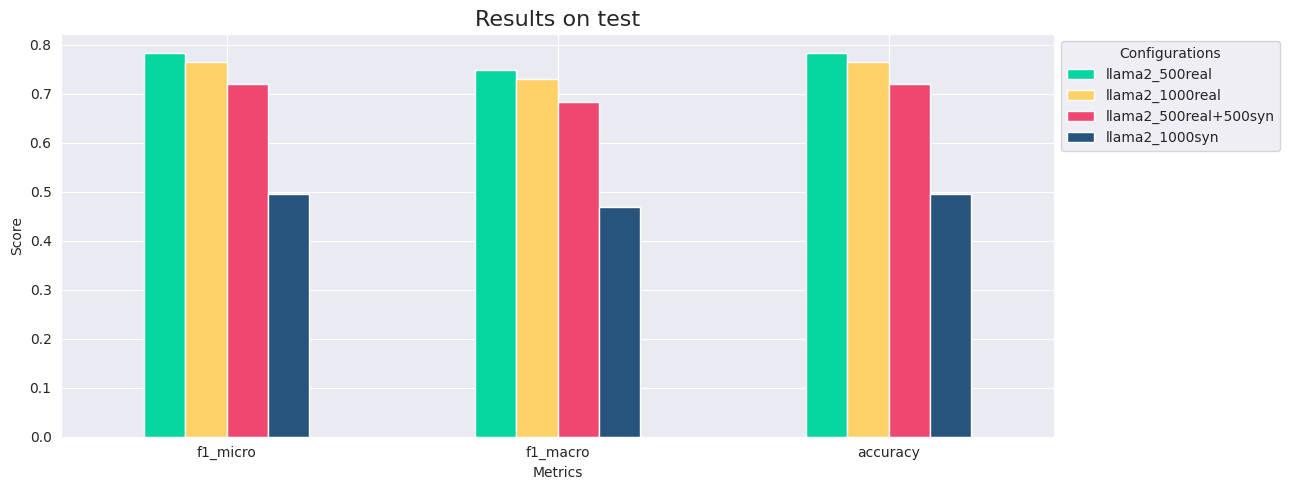

In [21]:
# df_results = pd.read_csv("../../agnews/experiments/adaptiveICL_1000samples/adaptiveICL_results_test.csv")

plot_df = df_results.set_index('name')
# plot_df["eval_time_norm"] = plot_df["eval_time"] / max(plot_df["eval_time"])
plot_df.drop(columns=["eval_time", "prepare_time"], inplace=True)
# colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c', '#aaaaaa']
colors = ['#06d6a0', '#ffd166', '#ef476f', '#26547c']
ax = plot_df.T.plot(kind='bar', figsize=(13, 5), color=colors)

plt.title('Results on test', fontsize=16)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Configurations', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()